# Examen bimestral N1
**Nombre:** Nicolas Paspuel

**Fecha:** 05/06/2026




In [40]:
# Primero se debe de importar las librerias necesarias para la ejecucion del programa
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


# **KPI 1: Tasa de Rotación de Personal (Attrition Rate)**
Mide la proporción de empleados que han salido de la organización en un periodo determinado. Este
KPI es un indicador de control crítico para la gestión estratégica: un porcentaje elevado alerta sobre
fallas en la retención del talento y un aumento inminente en los costos de reclutamiento y
capacitación. Se debe indicar para qué periodo de tiempo se calcula el Attrition Rate.

In [41]:
attrition = (df["Attrition"] == "Yes").sum()
total = len(df)
attrition_rate = (attrition / total) * 100
print("Tasa de rotacion de personal", attrition_rate, "%")

Tasa de rotacion de personal 16.122448979591837 %


La tasa de rotacion obtenida fue de **16.12%**, lo que indica que una parte importante de los empleados ha dejado la empresa. Este resultado puede ser una señal de que existen aspectos que afectan la permanencia del personal

# **KPI 2: Ingreso Promedio Mensual por Departamento**
Este indicador permite auditar las estructuras de compensación de la empresa. Desde la perspectiva
de la gobernanza corporativa, sirve para analizar e identificar brechas salariales estadísticas entre áreas
funcionales.

In [50]:
ingreso = df.groupby("Department")["MonthlyIncome"].mean()
print("Ingreso promedio mensual por departamento:", ingreso)


Ingreso promedio mensual por departamento: Department
Human Resources           6654.507937
Research & Development    6281.252862
Sales                     6959.172646
Name: MonthlyIncome, dtype: float64 $


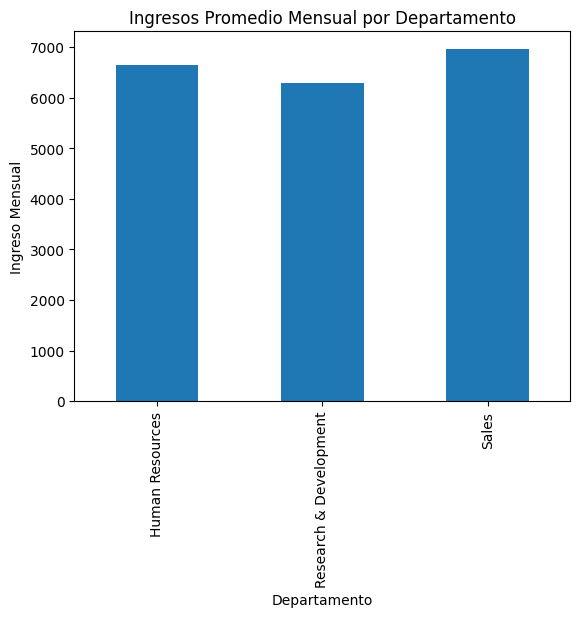

In [43]:
ingreso.plot(kind = "bar")
plt.title("Ingresos Promedio Mensual por Departamento")
plt.xlabel("Departamento")
plt.ylabel("Ingreso Mensual")
plt.show()

Se logra obsevar que **"Sales"** tiene el ingreso preomedio mas alto (**6959.17$**). Con esto podemos observar una diferencia de salario entre las distintas areas de la organizacion.

# **KPI 3: Índice de Balance Vida-Trabajo (Work-Life Balance Promedio) por Cargo**
Evalúa la calidad del entorno laboral y los riesgos de desgaste del personal. Al estructurarse por cargo
(JobRole), este KPI ayuda a la gerencia a identificar qué roles operativos específicos sufren sobrecarga,
actuando como un predictor temprano de futuras deserciones.

In [44]:
WorkLife = df.groupby("JobRole")["WorkLifeBalance"].mean()
print("Indice de Balance de Vida-Trabajo:", WorkLife)

Indice de Balance de Vida-Trabajo: JobRole
Healthcare Representative    2.702290
Human Resources              2.923077
Laboratory Technician        2.718147
Manager                      2.774510
Manufacturing Director       2.765517
Research Director            2.862500
Research Scientist           2.678082
Sales Executive              2.803681
Sales Representative         2.891566
Name: WorkLifeBalance, dtype: float64


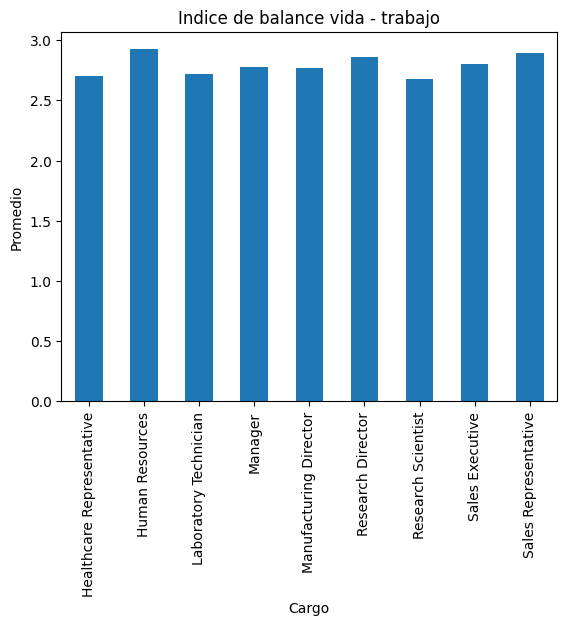

In [45]:
WorkLife.plot(kind = "bar")
plt.title("Indice de balance vida - trabajo")
plt.xlabel("Cargo")
plt.ylabel("Promedio")
plt.show()

Este KPI muesra como perciben los empleados el equilibrio entre su trabajo y su vida personal. Un valor bajo podria indicar que algunos cargos tienen una mayor carga laboral. En este caso se muestra que el **"Human Resource"** es el mas alto con un promedio (**2.92**).

# **KPI 4: Brecha de Estancamiento Laboral (Puesto Actual vs. Última Promoción)**
Analiza la fluidez de las líneas de carrera internas de la organización. Una brecha donde los años en el
puesto actual superan el tiempo transcurrido desde la última promoción revela estancamiento laboral
de los colaboradores activos, un factor que se vincula directamente con la baja productividad y pérdida
de motivación.

In [48]:
# Se crea una nueva columna
df["Brecha"] = df["YearsInCurrentRole"]-df["YearsSinceLastPromotion"]
BrechaLaboral = df["Brecha"].mean()
print("Brecha de estancamiento laboral:", BrechaLaboral)

Brecha de estancamiento laboral: 2.0414965986394558


La brecha promedio obtenida fue de **2.04 años**. Esto quiere decir que los empleados permanecen alrededor de dos años en su cargo. Este dato puede servir para evaluar las oportunidades de crecimiento dentro de la empresa